# Npy → DataContainer

Build a mumott `DataContainer` from a **ground-truth spherical-harmonics volume loaded directly
from an `.npy` file** (the global `GT_NPY_PATH`), rather than constructing it by binning a composite
volume as in `SyntheticDataContainers.ipynb`.

**Pipeline** (all steps after loading the ground truth are shared with `SyntheticDataContainers`
via `smartt.synthetic_dc.build_datacontainer_from_gt`):

1. Load the `(X, Y, Z, n_coeffs)` SH ground truth from `GT_NPY_PATH`.
2. Load a reference `DataContainer` (`REFERENCE_DC_PATH`) purely for detector metadata.
3. Generate `N_FIBONACCI` Fibonacci-hemisphere directions (honouring the missing wedge).
4. Forward-project the ground truth over those directions.
5. Wrap in a `DataContainer` and save `{dataset}.h5` **in the same folder as `GT_NPY_PATH`**.
6. Persist the ground truth in the `save_recon` npy+JSON-sidecar format (under
   `recon_cache/` next to the `.npy`) so benchmark notebooks can reload it with `load_recon`.

## 1 · Imports and Global Configuration

In [1]:
import sys, os
sys.path.insert(0, '/myhome/smartt')

import numpy as np
import matplotlib.pyplot as plt

from mumott.data_handling import DataContainer

from smartt.synthetic_dc import build_datacontainer_from_gt
from smartt.saxs_naf.cache import load_recon

# ── Global configuration ──────────────────────────────────────────────────────
# Ground-truth SH tensor, shape (X, Y, Z, n_coeffs). The DataContainer and the
# ground-truth cache are written into the SAME folder as this file.
GT_NPY_PATH = '/myhome/data/smartt/shared/synthetic_b411/ground_truth_b411.npy'

# Reference dataset: only its geometry metadata (detector_angles, two_theta,
# system vectors) is copied into the new geometry.
REFERENCE_DC_PATH = '/myhome/data/smartt/shared/b411/dataset_b411R_inf_1_0.220_1.900.h5'



DATASET_NAME        = 'dataset_from_npy'   # -> {DATASET_NAME}.h5
N_FIBONACCI         = 500                  # number of projection directions
ELL_MAX             = 8                    # SH order; must match GT n_coeffs (45 for ell_max=8)
MISSING_WEDGE_ANGLE = 45.0                 # half-opening angle of the missing wedge (deg)

OUTPUT_DIR = os.path.dirname(GT_NPY_PATH)  # save alongside the .npy
print(f"Ground truth : {GT_NPY_PATH}")
print(f"Reference DC : {REFERENCE_DC_PATH}")
print(f"Output dir   : {OUTPUT_DIR}")

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.
Ground truth : /myhome/data/smartt/shared/synthetic_b411/ground_truth_b411.npy
Reference DC : /myhome/data/smartt/shared/b411/dataset_b411R_inf_1_0.220_1.900.h5
Output dir   : /myhome/data/smartt/shared/synthetic_b411


## 2 · Load the Reference Geometry

In [2]:
# The reference DataContainer supplies detector geometry only (detector_angles,
# two_theta, system vectors); its data/shape are not used for the synthetic set.
ref_dc = DataContainer(REFERENCE_DC_PATH)
print(f"Reference DataContainer loaded: data {ref_dc.data.shape}, "
      f"{len(ref_dc.geometry.inner_angles)} projections")
print(f"detector_angles: {ref_dc.geometry.detector_angles.shape}")

INFO:Rotation matrices were loaded from the input file.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
Reference DataContainer loaded: data (266, 111, 86, 8), 266 projections
detector_angles: (8,)


## 3 · Load the Ground-Truth Volume

Ground-truth shape : (141, 111, 141, 45)   # expected (X, Y, Z, n_coeffs)
dtype              : float32
Value range        : [-995.4566, 1793.5818]


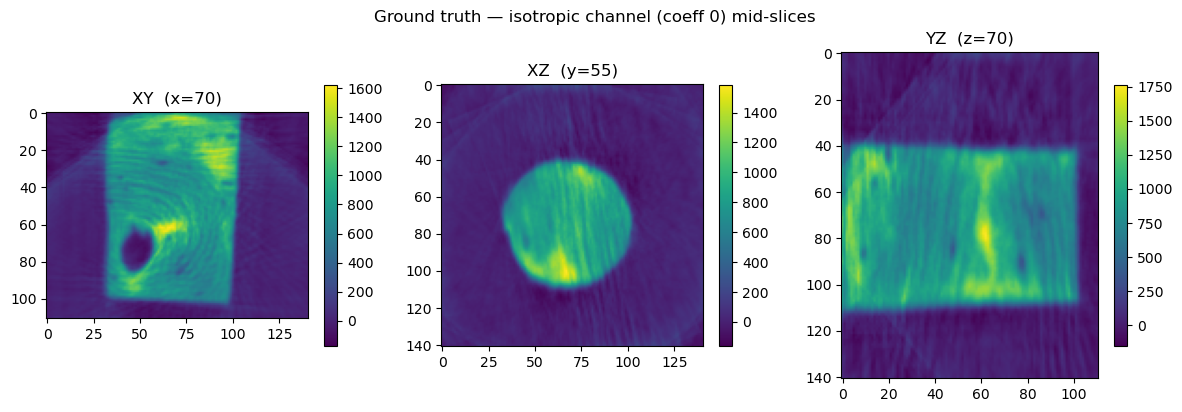

In [3]:
ground_truth = np.load(GT_NPY_PATH)
print(f"Ground-truth shape : {ground_truth.shape}   # expected (X, Y, Z, n_coeffs)")
print(f"dtype              : {ground_truth.dtype}")
print(f"Value range        : [{ground_truth.min():.4f}, {ground_truth.max():.4f}]")

expected_c = sum(2 * l + 1 for l in range(0, ELL_MAX + 1, 2))
assert ground_truth.ndim == 4, f"Expected 4-D (X,Y,Z,n_coeffs), got {ground_truth.shape}"
assert ground_truth.shape[-1] == expected_c, (
    f"GT has {ground_truth.shape[-1]} coefficients but ELL_MAX={ELL_MAX} "
    f"expects {expected_c}. Adjust ELL_MAX or the input volume.")

# Quick visual: isotropic channel (coeff 0) mid-slices
mid = np.array(ground_truth.shape[:3]) // 2
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (sl, title) in zip(axes, [
    (ground_truth[mid[0], :, :, 0], f'XY  (x={mid[0]})'),
    (ground_truth[:, mid[1], :, 0], f'XZ  (y={mid[1]})'),
    (ground_truth[:, :, mid[2], 0], f'YZ  (z={mid[2]})'),
]):
    im = ax.imshow(sl, cmap='viridis')
    ax.set_title(title)
    plt.colorbar(im, ax=ax, shrink=0.8)
plt.suptitle('Ground truth — isotropic channel (coeff 0) mid-slices', fontsize=12)
plt.tight_layout()
plt.show()

## 4 · Build and Save the DataContainer

`build_datacontainer_from_gt` runs the shared pipeline: Fibonacci geometry → forward projection →
`DataContainer` (saved to `{OUTPUT_DIR}/{DATASET_NAME}.h5`) → ground-truth cache
(`{OUTPUT_DIR}/recon_cache/`).

In [4]:
result = build_datacontainer_from_gt(
    ground_truth=ground_truth,
    reference_geometry=ref_dc.geometry,
    output_dir=OUTPUT_DIR,
    dataset_name=DATASET_NAME,
    n_fibonacci=N_FIBONACCI,
    ell_max=ELL_MAX,
    missing_wedge_angle=MISSING_WEDGE_ANGLE,
    gt_params=dict(source_npy=GT_NPY_PATH, reference_dc=REFERENCE_DC_PATH),
)

dc          = result['data_container']
save_path   = result['save_path']
gt_path     = result['gt_path']
gt_params   = result['gt_params']
cache_dir   = os.path.join(OUTPUT_DIR, 'recon_cache')

print(f"\nDataContainer : {save_path}")
print(f"  data shape  : {dc.data.shape}")
print(f"  projections : {len(dc.projections)}")
print(f"Ground truth  : {gt_path}")

[1] Generated 500 Fibonacci directions
[2] Geometry: 500 projections, volume_shape=(np.int64(141), np.int64(111), np.int64(141)), projection_shape=(np.int64(111), np.int64(141))
[3] Projection stack: (500, 111, 141, 8)
DataContainer saved to: /myhome/data/smartt/shared/synthetic_b411/dataset_from_npy.h5
[4] DataContainer saved to: /myhome/data/smartt/shared/synthetic_b411/dataset_from_npy.h5
[5] Ground truth saved to: /myhome/data/smartt/shared/synthetic_b411/recon_cache/ground_truth_01a4b51e.npy

DataContainer : /myhome/data/smartt/shared/synthetic_b411/dataset_from_npy.h5
  data shape  : (500, 111, 141, 8)
  projections : 500
Ground truth  : /myhome/data/smartt/shared/synthetic_b411/recon_cache/ground_truth_01a4b51e.npy


### Visualise a few forward projections

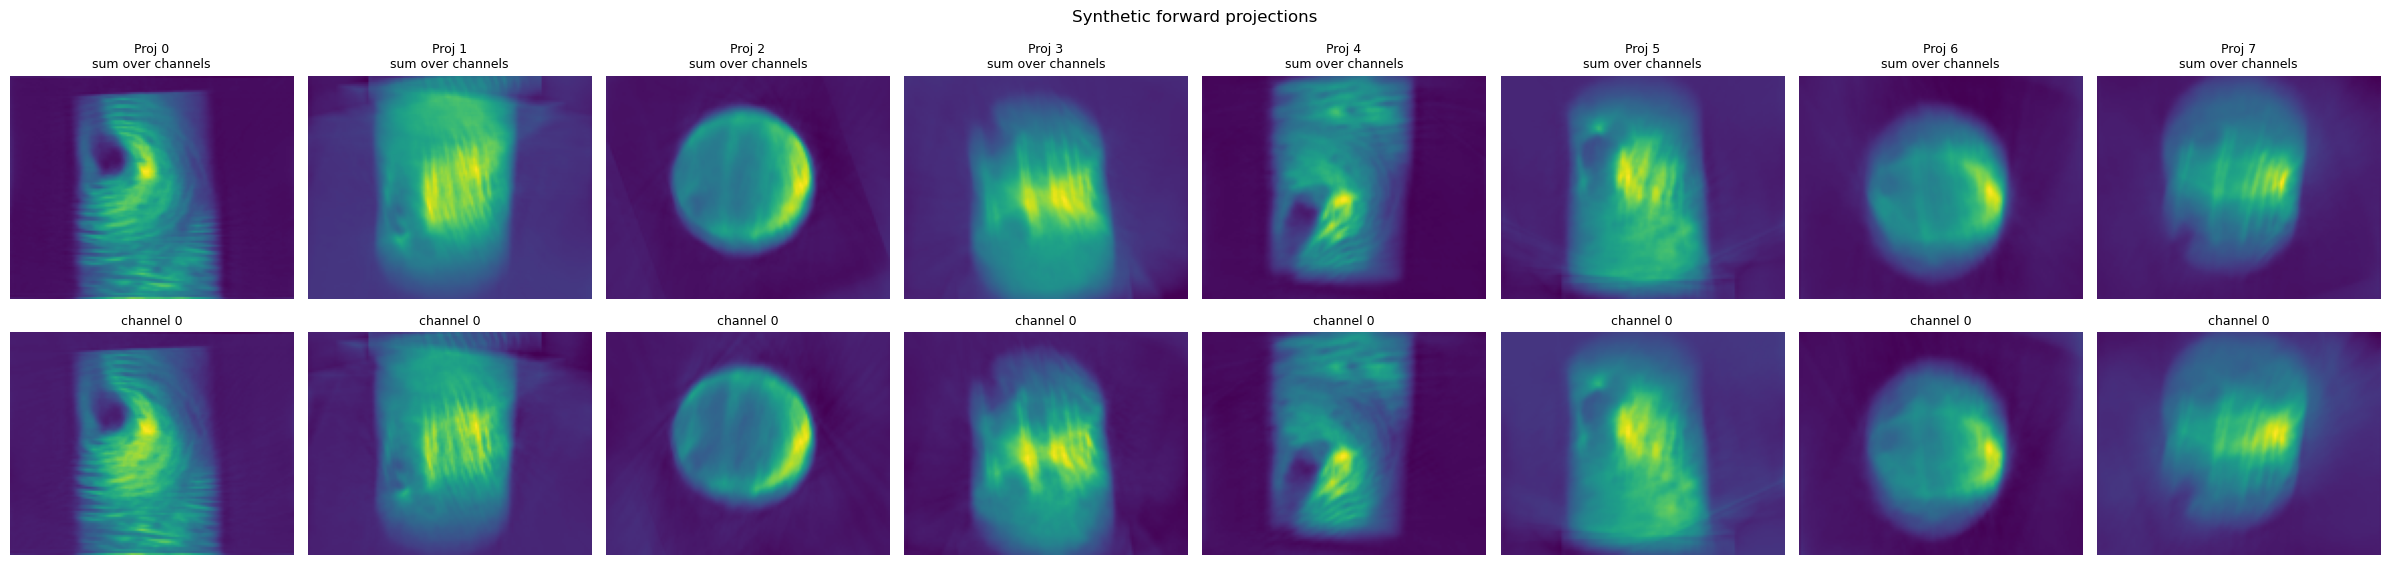

In [5]:
n_show = min(8, N_FIBONACCI)
fig, axes = plt.subplots(2, n_show, figsize=(3 * n_show, 6))
for i in range(n_show):
    axes[0, i].imshow(dc.data[i].sum(axis=-1), cmap='viridis')
    axes[0, i].set_title(f'Proj {i}\nsum over channels', fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(dc.data[i, :, :, 0], cmap='viridis')
    axes[1, i].set_title('channel 0', fontsize=9)
    axes[1, i].axis('off')
plt.suptitle('Synthetic forward projections', fontsize=12)
plt.tight_layout()
plt.show()

## 5 · Verify Round-Trip from Disk

In [6]:
# Reload the DataContainer and compare against the in-memory version.
dc_verify = DataContainer(save_path)
data_diff = np.max(np.abs(dc.data - dc_verify.data))
print(f"Reloaded DataContainer : data {dc_verify.data.shape}, "
      f"{len(dc_verify.geometry.inner_angles)} projections")
print(f"Max data difference (in-memory vs reloaded): {data_diff:.2e}  (should be 0)")

# Reload the ground-truth cache and compare against the source array.
gt_reloaded = load_recon(cache_dir, 'ground_truth', gt_params)
gt_diff = np.max(np.abs(ground_truth.astype(np.float32) - gt_reloaded))
print(f"\nReloaded ground truth  : shape {gt_reloaded.shape}")
print(f"Max GT difference (source vs reloaded): {gt_diff:.2e}  (should be 0)")

print("\nSummary")
print(f"  Source npy          : {GT_NPY_PATH}")
print(f"  Ground-truth shape  : {ground_truth.shape}")
print(f"  Projection directions: {N_FIBONACCI}")
print(f"  Saved DataContainer : {save_path}")
print(f"  Saved ground truth  : {gt_path}")

INFO:Inner axis found in projection 0. This will override the default value for all projections, if they do not specify another axis.
INFO:Inner axis found in projection 0. This will override the default value for all projections, if they do not specify another axis.
INFO:Rotation matrices were loaded from the input file.
INFO:Sample geometry loaded from file.
INFO:Detector geometry loaded from file.
Reloaded DataContainer : data (500, 111, 141, 8), 500 projections
Max data difference (in-memory vs reloaded): 0.00e+00  (should be 0)

Reloaded ground truth  : shape (141, 111, 141, 45)
Max GT difference (source vs reloaded): 0.00e+00  (should be 0)

Summary
  Source npy          : /myhome/data/smartt/shared/synthetic_b411/ground_truth_b411.npy
  Ground-truth shape  : (141, 111, 141, 45)
  Projection directions: 500
  Saved DataContainer : /myhome/data/smartt/shared/synthetic_b411/dataset_from_npy.h5
  Saved ground truth  : /myhome/data/smartt/shared/synthetic_b411/recon_cache/ground_trut